<a href="https://colab.research.google.com/github/ayishaarif6-gif/Supervised-machine-learning/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df=pd.read_csv('/content/Test.csv')

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [ ]:
df.describe()


,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2358.000000,2514.000000
mean,463433.918919,43.649791,2.552587,2.825378
std,2618.245698,16.967015,3.341094,1.551906
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,4.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [ ]:
df.shape

(2627, 10)

In [ ]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,50
Age,0
Graduated,24
Profession,38
Work_Experience,269
Spending_Score,0
Family_Size,113
Var_1,32


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=['ID','Var_1'],inplace=True)

In [ ]:
outlier_summary = {}

num_cols = ['Age', 'Work_Experience', 'Family_Size']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 19, 'Work_Experience': 58, 'Family_Size': 31}


In [ ]:
fill_missing_values_categorical = ['Ever_Married','Graduated','Profession']
fill_missing_values_numerical = ['Work_Experience','Family_Size']

for col in fill_missing_values_categorical:
  df[col] = df[col].fillna(df[col].mode()[0])

for col in fill_missing_values_numerical:
  df[col] = df[col].fillna(df[col].median())

In [ ]:
cols_to_cap = [
    'Age',
    'Work_Experience',
    'Family_Size',
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [ ]:
nominal_cols = ["Gender","Profession"] #onehot

# Filter nominal_cols to only include columns that are still in df
cols_to_encode = [col for col in nominal_cols if col in df.columns]

if cols_to_encode:
    df = pd.get_dummies(df,columns=cols_to_encode,drop_first=True)
else:
    print(f"Columns {nominal_cols} not found in DataFrame for one-hot encoding. They might have been already processed.")

In [ ]:
outlier_summary = {}

num_cols = ['Age', 'Work_Experience', 'Family_Size']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'Work_Experience': 0, 'Family_Size': 0}


In [ ]:
ordinal_columns = ['Spending_Score','Ever_Married','Graduated']
le = LabelEncoder()

for col in ordinal_columns:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
    elif col not in df.columns:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping encoding.")
    else:
        print(f"Column '{col}' is already numerical. Skipping encoding.")

In [ ]:
y = df['Spending_Score']
X = df.drop(columns=['Spending_Score'])


In [ ]:
X = df.drop(columns=['Spending_Score'])
y=df['Spending_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.8231939163498099

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.62      0.92      0.74       125
           1       0.81      0.61      0.70        77
           2       0.95      0.84      0.89       324

    accuracy                           0.82       526
   macro avg       0.80      0.79      0.78       526
weighted avg       0.85      0.82      0.83       526



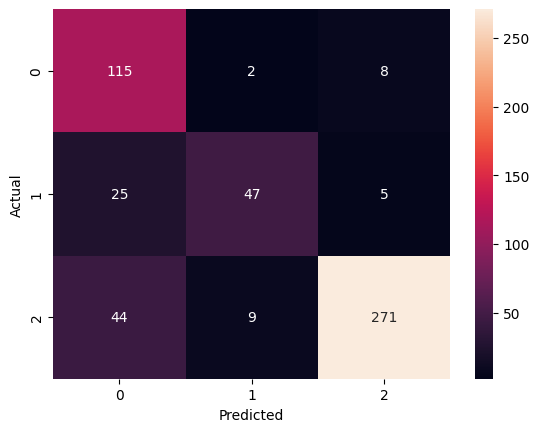

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,Ever_Married,0.375381
4,Family_Size,0.203157
1,Age,0.187815
9,Profession_Executive,0.068353
12,Profession_Lawyer,0.050958
10,Profession_Healthcare,0.032540
3,Work_Experience,0.028527
2,Graduated,0.015100
5,Gender_Male,0.013027
8,Profession_Entertainment,0.007834


In [ ]:
train_acc = rf.score(X_train, y_train)

test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8438838648262732
Testing Accuracy: 0.8231939163498099


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.80418251 0.81749049 0.82666667 0.79047619 0.78857143]
0.8054774579033135
